In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import shutil
import random
import numpy as np
import torch

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DATA_ROOT = "/content/drive/MyDrive/smear2005"
SPLIT_ROOT = "/content/drive/MyDrive/smear_split"

def split_dataset():
    classes = os.listdir(DATA_ROOT)

    for cls in classes:
        images = os.listdir(os.path.join(DATA_ROOT, cls))
        random.shuffle(images)

        train_split = int(0.7 * len(images))
        val_split   = int(0.85 * len(images))

        splits = {
            "train": images[:train_split],
            "val": images[train_split:val_split],
            "test": images[val_split:]
        }

        for split in splits:
            split_path = os.path.join(SPLIT_ROOT, split, cls)
            os.makedirs(split_path, exist_ok=True)

            for img in splits[split]:
                src = os.path.join(DATA_ROOT, cls, img)
                dst = os.path.join(split_path, img)

                if not os.path.exists(dst):
                    shutil.copy(src, dst)

# Run only once
#split_dataset()

In [ ]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((256, 256)),          # better resolution for EfficientNet
    transforms.RandomResizedCrop(224),      # improves generalization
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.Resize((256, 256)),          # keep consistent scaling
    transforms.CenterCrop(224),             # stable evaluation
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

In [ ]:
from torch.utils.data import DataLoader
from torchvision import datasets
import os

def get_dataloaders(data_root, batch_size=32):

    train_dir = os.path.join(data_root, "train")
    val_dir   = os.path.join(data_root, "val")
    test_dir  = os.path.join(data_root, "test")

    train_data = datasets.ImageFolder(train_dir, transform=train_transform)
    val_data   = datasets.ImageFolder(val_dir, transform=val_test_transform)
    test_data  = datasets.ImageFolder(test_dir, transform=val_test_transform)

    train_loader = DataLoader(
        train_data, batch_size=batch_size, shuffle=True,
        num_workers=2, pin_memory=True
    )

    val_loader = DataLoader(
        val_data, batch_size=batch_size, shuffle=False,
        num_workers=2, pin_memory=True
    )

    test_loader = DataLoader(
        test_data, batch_size=batch_size, shuffle=False,
        num_workers=2, pin_memory=True
    )

    return train_loader, val_loader, test_loader

In [ ]:
import torch
import torch.nn as nn
from torchvision import models
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_classes = 7

# Load pretrained EfficientNet
model = models.efficientnet_b0(pretrained=True)

# Freeze all layers
for param in model.parameters():
    param.requires_grad = False

# Unfreeze last feature block
for param in model.features[-3].parameters():
    param.requires_grad = True

# Replace classifier
in_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(in_features, num_classes)

# Move to device (if not already done)
model = model.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 149MB/s]


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

criterion = nn.CrossEntropyLoss()

# 🔥 IMPORTANT FIX
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=5e-5
)

In [ ]:
def train_model(model, train_loader, val_loader, epochs=20):

    best_val_acc = 0

    for epoch in range(epochs):
        model.train()
        train_loss = 0

        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * imgs.size(0)

        train_loss = train_loss / len(train_loader.dataset)

        val_acc = evaluate(model, val_loader, print_result=False)

        print(f"Epoch {epoch+1}")
        print(f"Train Loss: {train_loss:.4f}")
        print(f"Val Accuracy: {val_acc:.2f}%")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), "efficientnet_best.pth")
            print("✅ Model Saved!")

        print("-" * 30)

In [ ]:
def evaluate(model, loader, print_result=True):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)

            outputs = model(imgs)
            _, preds = torch.max(outputs, 1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    acc = 100 * correct / total

    if print_result:
        print(f"Accuracy: {acc:.2f}%")

    return acc

In [ ]:
train_loader, val_loader, test_loader = get_dataloaders(SPLIT_ROOT)

train_model(model, train_loader, val_loader, epochs=20)

print("🔍 Loading Best Model...")
model.load_state_dict(torch.load("efficientnet_best.pth"))

print("Validation:")
evaluate(model, val_loader)

print("Test:")
evaluate(model, test_loader)

Epoch 1
Train Loss: 1.9023
Val Accuracy: 31.47%
✅ Model Saved!
------------------------------
Epoch 2
Train Loss: 1.7856
Val Accuracy: 38.66%
✅ Model Saved!
------------------------------
Epoch 3
Train Loss: 1.6804
Val Accuracy: 42.56%
✅ Model Saved!
------------------------------
Epoch 4
Train Loss: 1.6015
Val Accuracy: 44.96%
✅ Model Saved!
------------------------------
Epoch 5
Train Loss: 1.5256
Val Accuracy: 45.15%
✅ Model Saved!
------------------------------
Epoch 6
Train Loss: 1.4626
Val Accuracy: 48.15%
✅ Model Saved!
------------------------------
Epoch 7
Train Loss: 1.4174
Val Accuracy: 48.15%
------------------------------
Epoch 8
Train Loss: 1.3769
Val Accuracy: 49.35%
✅ Model Saved!
------------------------------
Epoch 9
Train Loss: 1.3422
Val Accuracy: 53.85%
✅ Model Saved!
------------------------------
Epoch 10
Train Loss: 1.3158
Val Accuracy: 54.15%
✅ Model Saved!
------------------------------
Epoch 11
Train Loss: 1.2959
Val Accuracy: 56.04%
✅ Model Saved!
----------

65.77946768060836

In [ ]:
!pip install shap

In [ ]:
import os

os.makedirs("explanations", exist_ok=True)

In [ ]:
import shap
import numpy as np
import matplotlib.pyplot as plt
import torch
import os

def apply_shap(model, loader, device, num_images=5, save_path="shap_explanations/"):

    model.eval()
    os.makedirs(save_path, exist_ok=True)

    # 🔥 Step 1: Background dataset (IMPORTANT)
    background = []
    for imgs, _ in loader:
        background.append(imgs)
        if len(background) * imgs.size(0) >= 20:
            break

    background = torch.cat(background)[:20].to(device)

    # 🔥 Step 2: SHAP Explainer
    explainer = shap.GradientExplainer(model, background)

    count = 0

    for imgs, labels in loader:
        imgs = imgs.to(device)

        for i in range(imgs.size(0)):
            if count >= num_images:
                return

            input_tensor = imgs[i].unsqueeze(0)

            # 🔥 Step 3: SHAP values
            shap_values = explainer.shap_values(input_tensor)

            # 🔥 Step 4: Prediction
            with torch.no_grad():
                output = model(input_tensor)
                probs = torch.softmax(output, dim=1)
                pred_class = torch.argmax(probs, dim=1).item()
                conf = probs[0, pred_class].item()

            # 🔥 Step 5: Convert SHAP → numpy safely
            sv = shap_values

            if hasattr(sv, "cpu"):
                sv = sv.cpu().numpy()

            # 🔥 Step 6: HANDLE ALL SHAP FORMATS

            if isinstance(sv, list):
                # case 1: list per class
                sv = sv[pred_class][0]   # (C,H,W)
                shap_map = np.mean(np.abs(sv), axis=0)

            elif isinstance(sv, np.ndarray):

                if sv.ndim == 5:
                    # rare: (1, C, H, W, classes)
                    sv = sv[0]

                if sv.ndim == 4:
                    # your case: (C,H,W,classes)
                    sv = sv[:, :, :, pred_class]   # (C,H,W)
                    shap_map = np.mean(np.abs(sv), axis=0)

                elif sv.ndim == 3:
                    # (C,H,W)
                    shap_map = np.mean(np.abs(sv), axis=0)

                elif sv.ndim == 2:
                    # (H,W)
                    shap_map = np.abs(sv)

                else:
                    raise ValueError(f"Unhandled SHAP shape: {sv.shape}")

            else:
                raise ValueError("Unknown SHAP format")

            # 🔥 Step 7: Normalize heatmap
            shap_map = (shap_map - shap_map.min()) / (shap_map.max() + 1e-8)

            # 🔥 Step 8: Original image (denormalize)
            img = imgs[i].cpu().numpy().transpose(1, 2, 0)

            mean = np.array([0.485, 0.456, 0.406])
            std = np.array([0.229, 0.224, 0.225])
            img = std * img + mean
            img = np.clip(img, 0, 1)

            # 🔥 Step 9: Overlay
            plt.figure(figsize=(6,6))
            plt.imshow(img)
            plt.imshow(shap_map, cmap='jet', alpha=0.5)

            plt.title(f"True: {labels[i].item()} | Pred: {pred_class} | Conf: {conf:.2f}")
            plt.axis("off")

            plt.savefig(f"{save_path}shap_{count}.png")
            plt.show()

            count += 1

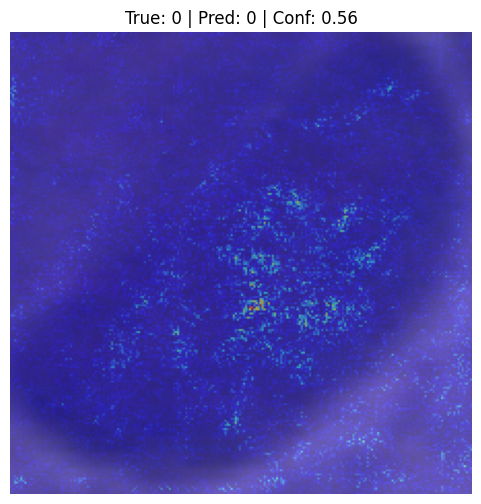

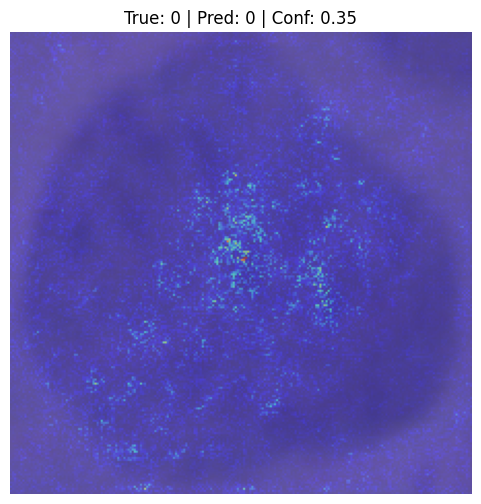

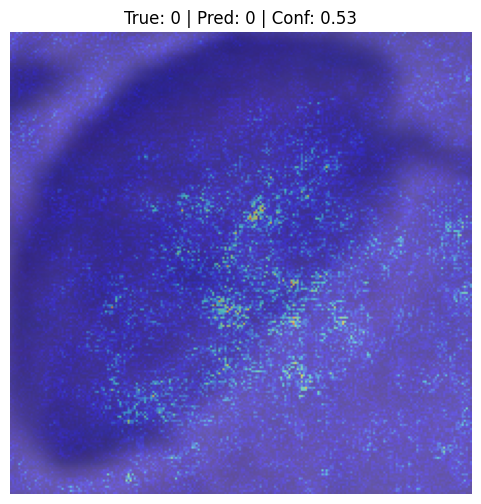

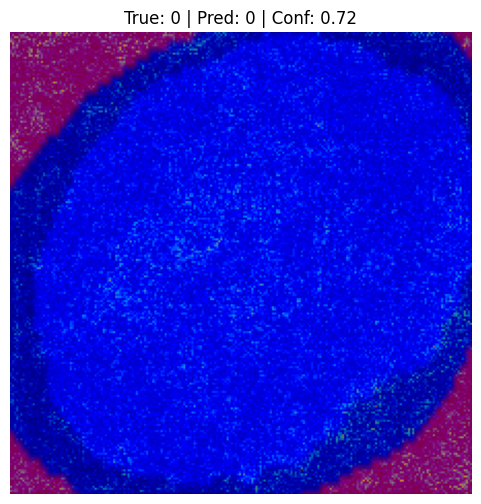

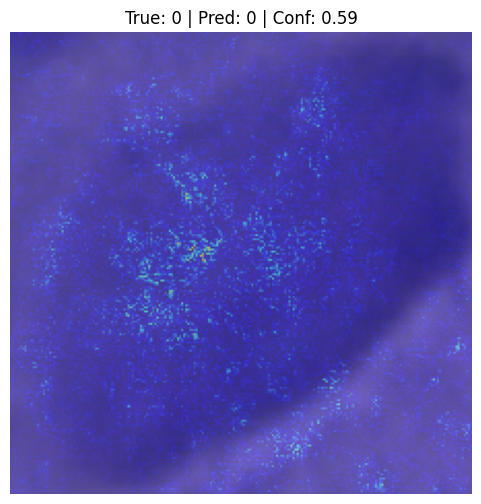

In [ ]:
apply_shap(model, test_loader, device)

In [ ]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt
import numpy as np
import torch


def evaluate_metrics(model, loader, class_names):

    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():

        for imgs, labels in loader:

            imgs = imgs.to(device)
            labels = labels.to(device)

            outputs = model(imgs)

            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Classification Report
    print("\n📊 Classification Report:\n")

    print(
        classification_report(
            all_labels,
            all_preds,
            target_names=class_names,
            digits=4
        )
    )

    # Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)

    plt.figure(figsize=(8,8))

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=class_names
    )

    disp.plot(cmap="Blues", xticks_rotation=45)

    plt.title("Confusion Matrix")

    plt.show()


📊 Classification Report:

                     precision    recall  f1-score   support

  carcinoma_in_situ     0.7500    0.6250    0.6818       168
   light_dysplastic     0.6175    0.8421    0.7126       209
moderate_dysplastic     0.5319    0.4464    0.4854       168
    normal_columnar     0.7500    0.4636    0.5730       110
normal_intermediate     0.7978    0.8987    0.8452        79
 normal_superficiel     0.9036    0.8721    0.8876        86
  severe_dysplastic     0.5650    0.5991    0.5816       232

           accuracy                         0.6578      1052
          macro avg     0.7023    0.6782    0.6810      1052
       weighted avg     0.6642    0.6578    0.6522      1052



<Figure size 800x800 with 0 Axes>

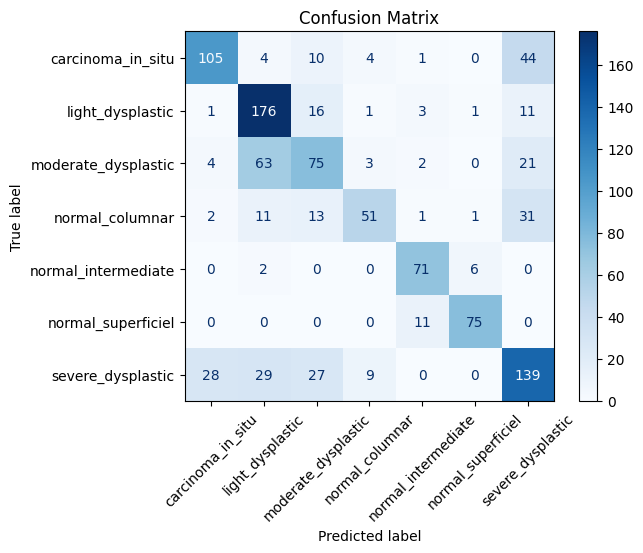

In [ ]:
class_names = train_loader.dataset.classes

evaluate_metrics(model, test_loader, class_names)

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
model.eval()

all_labels = []
all_probs = []

with torch.no_grad():
    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        probs = torch.softmax(outputs, dim=1)

        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_probs = np.array(all_probs)
all_labels = np.array(all_labels)

In [ ]:
num_classes = len(class_names)

# Convert labels to one-hot format
all_labels_bin = label_binarize(all_labels, classes=range(num_classes))

fpr = {}
tpr = {}
roc_auc = {}

for i in range(num_classes):

    fpr[i], tpr[i], _ = roc_curve(
        all_labels_bin[:, i],
        all_probs[:, i]
    )

    roc_auc[i] = auc(fpr[i], tpr[i])

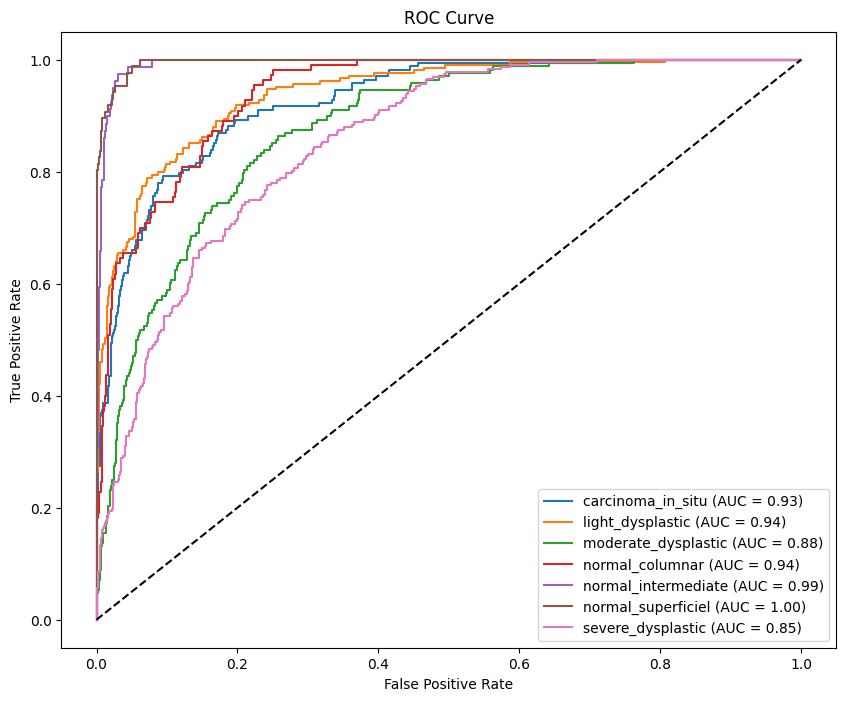

In [ ]:
plt.figure(figsize=(10, 8))

for i in range(num_classes):
    plt.plot(
        fpr[i],
        tpr[i],
        label=f'{class_names[i]} (AUC = {roc_auc[i]:.2f})'
    )

plt.plot([0, 1], [0, 1], 'k--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()

plt.savefig("roc_curve_efficientnet.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
from sklearn.metrics import classification_report
import pandas as pd

report = classification_report(
    all_labels,
    np.argmax(all_probs, axis=1),
    target_names=class_names,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

print(report_df)

                     precision    recall  f1-score      support
carcinoma_in_situ     0.750000  0.625000  0.681818   168.000000
light_dysplastic      0.617544  0.842105  0.712551   209.000000
moderate_dysplastic   0.531915  0.446429  0.485437   168.000000
normal_columnar       0.750000  0.463636  0.573034   110.000000
normal_intermediate   0.797753  0.898734  0.845238    79.000000
normal_superficiel    0.903614  0.872093  0.887574    86.000000
severe_dysplastic     0.565041  0.599138  0.581590   232.000000
accuracy              0.657795  0.657795  0.657795     0.657795
macro avg             0.702267  0.678162  0.681034  1052.000000
weighted avg          0.664212  0.657795  0.652177  1052.000000


In [ ]:
report_df.to_csv("classification_report_EfficientNet.csv")

In [ ]:
import os
from torchvision.utils import save_image

error_dir = "/content/drive/MyDrive/misclassified_samples_Efficientnet"
os.makedirs(error_dir, exist_ok=True)

model.eval()

with torch.no_grad():

    count = 0

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)

        for i in range(len(preds)):

            if preds[i] != labels[i]:

                true_label = class_names[labels[i]]
                pred_label = class_names[preds[i]]

                save_path = os.path.join(
                    error_dir,
                    f"true_{true_label}_pred_{pred_label}_{count}.png"
                )

                save_image(images[i].cpu(), save_path)

                count += 1